# 🏎️ Lights Out and Away We Go — Part 2
## From ML Predictions to Agentic Race Strategy
### Microsoft Foundry × LangGraph × Azure ML

---

> **Part 1** gave us a model that predicts *should we pit?* with 88% accuracy.  
> **Part 2** gives that model a brain — an agent that *reasons* about the race like a strategy engineer.

---

### What changes?

| Part 1 — Azure ML | Part 2 — Foundry + LangGraph |
|---|---|
| Input exact numbers, get a number back | Ask in plain English, get a strategic decision |
| One prediction at a time | Reasons across multiple tools |
| No context awareness | Understands race situation holistically |
| `pit_recommended = 1` | *"Box this lap. Gap behind is closing. Safety car window is open."* |

---

### Architecture

```
You (natural language)
        │
        ▼
┌─────────────────────────────┐
│   LangGraph ReAct Agent     │  ← Azure OpenAI / Foundry
│   "F1 Strategy Engineer"    │
└──────────┬──────────────────┘
           │ calls tools
    ┌──────┴────────────────┐
    │                       │
    ▼                       ▼
pit_prediction_tool    get_race_conditions_tool
(Azure ML endpoint)    (simulated telemetry feed)
    │                       │
    └──────────┬────────────┘
               │ combines results
               ▼
   Natural language strategy decision
```


---
## Step 0 — Install Dependencies

In [ ]:
# Install required packages
# Run this cell once, then restart kernel if needed
import subprocess, sys

packages = [
    "langgraph",
    "langchain",
    "langchain-openai",
    "langchain-core",
    "openai",
    "python-dotenv",
    "joblib",
    "scikit-learn",
    "pandas",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✅ Packages ready")

---
## Step 1 — Configuration

Two modes:
- **Local mode** (no Azure needed) — calls your trained model file directly. Perfect for the demo.
- **Azure ML mode** — calls a deployed endpoint. Set env vars to activate.

For Azure OpenAI / Foundry, set your endpoint in the cell below.

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

# -- Azure OpenAI / Foundry config -----------------------------------------
# Keep defaults empty so mistakes are visible instead of silently using bad values.
# Set these in your environment or .env file.

AZURE_OPENAI_ENDPOINT     = os.getenv("AZURE_OPENAI_ENDPOINT", "").strip()      # e.g. https://<resource>.openai.azure.com
AZURE_OPENAI_API_KEY      = os.getenv("AZURE_OPENAI_API_KEY", "").strip()        # Azure OpenAI key
AZURE_OPENAI_DEPLOYMENT   = os.getenv("AZURE_OPENAI_DEPLOYMENT", "").strip()     # deployment name, not model family name
AZURE_OPENAI_API_VERSION  = os.getenv("AZURE_OPENAI_API_VERSION", "2024-10-21").strip()

# -- Azure ML endpoint config (optional) -----------------------------------
AZURE_ML_ENDPOINT_URL = os.getenv("AZURE_ML_ENDPOINT_URL", "")
AZURE_ML_ENDPOINT_KEY = os.getenv("AZURE_ML_ENDPOINT_KEY", "")

# -- Auto-detect mode -------------------------------------------------------
USE_AZURE_OPENAI = bool(AZURE_OPENAI_ENDPOINT and AZURE_OPENAI_API_KEY and AZURE_OPENAI_DEPLOYMENT)
USE_AZURE_ML     = bool(AZURE_ML_ENDPOINT_URL and AZURE_ML_ENDPOINT_KEY)

print(f"LLM backend:      {'Azure OpenAI / Foundry' if USE_AZURE_OPENAI else 'OpenAI (set OPENAI_API_KEY)'}")
print(f"Prediction model: {'Azure ML endpoint' if USE_AZURE_ML else 'Local model file (model/pit_model.pkl)'}")
print()

if not USE_AZURE_OPENAI:
    print("Tip: Azure OpenAI vars are incomplete (need endpoint, key, deployment). Falling back to OpenAI if OPENAI_API_KEY is set.")

print("Tip: Both prediction modes produce identical demo output for the audience.")

LLM backend:      Azure OpenAI / Foundry
Prediction model: Local model file (model/pit_model.pkl)

Tip: Both prediction modes produce identical demo output for the audience.


---
## Step 2 — Load the LLM (Azure OpenAI / Foundry)

This is the "brain" of the agent — the model that reasons and decides when to call tools.

In [9]:
from langchain_openai import AzureChatOpenAI, ChatOpenAI

if USE_AZURE_OPENAI:
    llm = AzureChatOpenAI(
        azure_endpoint=AZURE_OPENAI_ENDPOINT,
        api_key=AZURE_OPENAI_API_KEY,
        azure_deployment=AZURE_OPENAI_DEPLOYMENT,
        api_version=AZURE_OPENAI_API_VERSION,
        temperature=0.1,   # Low temp = consistent, decisive strategy calls
    )

    # Preflight call so endpoint/deployment/version issues fail early and clearly.
    try:
        _ = llm.invoke("Return exactly: OK")
        print(f"Connected to Azure OpenAI / Foundry - deployment: {AZURE_OPENAI_DEPLOYMENT}")
    except Exception as e:
        err = str(e)
        if "404" in err or "Resource not found" in err:
            raise RuntimeError(
                "Azure OpenAI returned 404 (Resource not found). Check: \n"
                "1) AZURE_OPENAI_ENDPOINT is your Azure OpenAI endpoint (usually *.openai.azure.com),\n"
                "2) AZURE_OPENAI_DEPLOYMENT matches an existing deployment name exactly,\n"
                "3) AZURE_OPENAI_API_VERSION is valid for that deployment.\n"
                f"Current endpoint={AZURE_OPENAI_ENDPOINT}, deployment={AZURE_OPENAI_DEPLOYMENT}, api_version={AZURE_OPENAI_API_VERSION}"
            ) from e
        raise
else:
    # Fallback: standard OpenAI
    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        temperature=0.1,
        api_key=os.getenv("OPENAI_API_KEY", "your-key-here")
    )
    print("Using OpenAI directly")

print("\nLLM ready - the strategy engineer brain is online.")

Connected to Azure OpenAI / Foundry - deployment: gpt-5.4-mini

LLM ready - the strategy engineer brain is online.


---
## Step 3 — Define the Tools

Tools are what make an agent different from a chatbot.  
The agent *decides* when to call these — you don't hardcode the flow.

We give our F1 Strategy Agent two tools:
1. **`pit_prediction_tool`** — calls the Azure ML model from Part 1
2. **`get_race_conditions_tool`** — returns simulated live race data (weather, safety car, gaps)

In [8]:
import json
import requests
import joblib
import pandas as pd
from pathlib import Path
from langchain_core.tools import tool

# ── Load local model (used when no Azure ML endpoint is configured) ────────
local_model = None
if not USE_AZURE_ML:
    model_path = Path("model/pit_model.pkl")
    if model_path.exists():
        local_model = joblib.load(model_path)
        print("✅ Local model loaded from model/pit_model.pkl")
    else:
        print("⚠️  Local model not found. Run deploy_model.py first, or set Azure ML env vars.")

FEATURES = [
    "tyre_age", "lap_time_delta", "compound_encoded",
    "gap_to_car_behind", "gap_to_car_ahead",
    "fuel_effect", "safety_car"
]


# ══════════════════════════════════════════════════════════════════════════
# TOOL 1: Pit prediction — calls Azure ML (or local model)
# ══════════════════════════════════════════════════════════════════════════
@tool
def pit_prediction_tool(
    tyre_age: int,
    lap_time_delta: float,
    tyre_compound: str,
    gap_to_car_behind: float,
    gap_to_car_ahead: float,
    fuel_effect: float = 0.5,
    safety_car: int = 0
) -> str:
    """
    Predicts whether to recommend a pit stop based on current race telemetry.
    Call this tool whenever you need a data-driven pit stop recommendation.

    Args:
        tyre_age: Number of laps on current tyre set
        lap_time_delta: Lap time vs fresh tyre baseline in seconds (positive = slower)
        tyre_compound: One of 'soft', 'medium', 'hard'
        gap_to_car_behind: Gap to car behind in seconds
        gap_to_car_ahead: Gap to car ahead in seconds
        fuel_effect: Time lost from remaining fuel weight (default 0.5)
        safety_car: 1 if safety car is deployed, 0 if green flag racing

    Returns:
        JSON string with pit_recommended (0/1), confidence %, and probabilities
    """
    compound_map = {"soft": 2, "medium": 1, "hard": 0}
    compound_encoded = compound_map.get(tyre_compound.lower(), 1)

    input_data = {
        "tyre_age": tyre_age,
        "lap_time_delta": lap_time_delta,
        "compound_encoded": compound_encoded,
        "gap_to_car_behind": gap_to_car_behind,
        "gap_to_car_ahead": gap_to_car_ahead,
        "fuel_effect": fuel_effect,
        "safety_car": safety_car
    }

    if USE_AZURE_ML:
        # ── Call Azure ML real-time endpoint ──────────────────────────────
        try:
            response = requests.post(
                AZURE_ML_ENDPOINT_URL,
                headers={
                    "Content-Type": "application/json",
                    "Authorization": f"Bearer {AZURE_ML_ENDPOINT_KEY}"
                },
                json={"input": input_data},
                timeout=10
            )
            result = response.json()
        except Exception as e:
            return json.dumps({"error": f"Azure ML endpoint error: {str(e)}"})
    else:
        # ── Call local model directly ─────────────────────────────────────
        if local_model is None:
            return json.dumps({"error": "No model available. Run deploy_model.py first."})

        df = pd.DataFrame([input_data])
        pred  = int(local_model.predict(df[FEATURES])[0])
        proba = local_model.predict_proba(df[FEATURES])[0].tolist()
        result = {
            "pit_recommended": pred,
            "confidence": round(max(proba) * 100, 1),
            "stay_out_probability": round(proba[0] * 100, 1),
            "pit_probability": round(proba[1] * 100, 1),
            "source": "local_model"  # shows 'azure_ml_endpoint' in production
        }

    return json.dumps(result)


# ══════════════════════════════════════════════════════════════════════════
# TOOL 2: Live race conditions (simulated telemetry feed)
# ══════════════════════════════════════════════════════════════════════════
@tool
def get_race_conditions_tool(lap: int) -> str:
    """
    Returns current race conditions including weather, safety car status,
    track temperature, and competitor strategy information.
    Call this when you need broader race context to inform strategy.

    Args:
        lap: Current lap number

    Returns:
        JSON string with weather, track conditions, and competitor info
    """
    # Simulated race conditions — in production this calls a live telemetry API
    import random
    random.seed(lap)  # deterministic for same lap = consistent demo

    conditions = {
        "lap": lap,
        "weather": "dry" if lap < 40 else "light_drizzle",
        "track_temp_celsius": 38 + (lap % 5),
        "air_temp_celsius": 28,
        "safety_car_active": lap in [12, 13, 34, 35],  # known SC laps
        "vsc_active": False,
        "drs_enabled": True,
        "competitors": {
            "P1_leader_tyre_age": max(1, 22 - (lap % 8)),
            "P1_compound": "medium",
            "p2_gap_to_leader": round(2.1 + lap * 0.08, 1),
            "p3_gap_to_leader": round(5.4 + lap * 0.12, 1),
        },
        "pit_lane_time_loss": 22.5,
        "tyre_availability": {
            "soft": 0,    # used both sets
            "medium": 1,  # one set remaining
            "hard": 2     # two sets remaining
        },
        "source": "simulated_telemetry_feed"
    }
    return json.dumps(conditions)


tools = [pit_prediction_tool, get_race_conditions_tool]
print(f"✅ {len(tools)} tools registered:")
for t in tools:
    print(f"   • {t.name}")

✅ Local model loaded from model/pit_model.pkl
✅ 2 tools registered:
   • pit_prediction_tool
   • get_race_conditions_tool


---
## Step 4 — Build the LangGraph Agent

This is where **LangGraph** comes in.  
We use the `create_react_agent` pattern — **ReAct** = **Re**ason + **Act**.

The agent loop:
```
Think → Call a tool → Observe result → Think again → Answer
```

This is exactly what a human strategy engineer does on the pit wall.

In [10]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage, SystemMessage

# ── System prompt: defines the agent's persona and knowledge ──────────────
SYSTEM_PROMPT = """
You are an elite F1 race strategist for the Mercedes-AMG PETRONAS Formula One Team.
You work on the pit wall alongside engineers powered by Microsoft Azure AI.

Your role is to make real-time pit stop strategy decisions during a Grand Prix.
You have access to two tools:
  1. pit_prediction_tool — an Azure ML model trained on race telemetry that predicts
     whether a pit stop is recommended based on tyre age, lap time delta, and race gaps.
  2. get_race_conditions_tool — returns live race conditions: weather, safety car,
     track temperature, and competitor strategy information.

ALWAYS call pit_prediction_tool first when asked about a pit stop decision.
ALWAYS call get_race_conditions_tool to get broader race context.
Then reason over both results and give a clear, confident strategic recommendation.

Your responses should:
  - Start with a clear YES/NO pit recommendation
  - Explain WHY in 2-3 bullet points (tyre data, race context, strategic reasoning)
  - Mention the model confidence percentage
  - Suggest the best compound to fit if pitting
  - Be decisive — indecision costs races

Use F1 terminology naturally: undercut, overcut, pit window, DRS, VSC, safety car delta.
Keep responses concise — the race doesn't stop for long explanations.
"""

# ── Create the ReAct agent ────────────────────────────────────────────────
agent = create_react_agent(
    model=llm.bind_tools(tools),
    tools=tools,
)

print("✅ LangGraph ReAct agent created")
print("📻 The pit wall is live. Ready to receive strategy queries.")

✅ LangGraph ReAct agent created
📻 The pit wall is live. Ready to receive strategy queries.


---
## Step 5 — Helper: Pretty Print Agent Reasoning

This shows the audience *how* the agent thinks — each tool call and response visible step by step.

In [11]:
def ask_strategy_agent(question: str, show_reasoning: bool = True) -> str:
    """
    Send a question to the F1 strategy agent and display its reasoning.
    """
    MERC_TEAL = "\033[96m"   # Cyan (closest to Mercedes teal in terminal)
    BOLD      = "\033[1m"
    DIM       = "\033[2m"
    RESET     = "\033[0m"

    print(f"\n{BOLD}{'='*60}{RESET}")
    print(f"{BOLD}  PIT WALL QUERY{RESET}")
    print(f"{BOLD}{'='*60}{RESET}")
    print(f"  {question}")
    print(f"{DIM}{'-'*60}{RESET}")

    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=question)
    ]

    try:
        result = agent.invoke({"messages": messages})
    except Exception as e:
        err = str(e)
        if "404" in err and "Resource not found" in err:
            raise RuntimeError(
                "LLM call failed with Azure 404 Resource not found. This usually means endpoint/deployment/API version mismatch. "
                "Re-run Step 1 and Step 2 after correcting AZURE_OPENAI_ENDPOINT, AZURE_OPENAI_DEPLOYMENT, and AZURE_OPENAI_API_VERSION."
            ) from e
        raise

    if show_reasoning:
        print(f"\n{DIM}  Agent reasoning steps:{RESET}")
        for msg in result["messages"]:
            msg_type = type(msg).__name__
            if "ToolCall" in str(type(msg)) or (hasattr(msg, "tool_calls") and msg.tool_calls):
                for tc in msg.tool_calls:
                    print(f"{MERC_TEAL}  -> Calling tool: {tc['name']}{RESET}")
                    args_preview = str(tc['args'])[:120]
                    print(f"{DIM}    args: {args_preview}...{RESET}" if len(str(tc['args'])) > 120
                          else f"{DIM}    args: {tc['args']}{RESET}")
            elif "ToolMessage" in msg_type:
                content_preview = msg.content[:200]
                print(f"{MERC_TEAL}  <- Tool result: {content_preview}{'...' if len(msg.content) > 200 else ''}{RESET}")

    # Final response
    final_response = result["messages"][-1].content
    print(f"\n{BOLD}{'-'*60}")
    print(f"  STRATEGY DECISION{RESET}")
    print(f"{BOLD}{'-'*60}{RESET}")
    print(f"\n{final_response}")
    print(f"\n{BOLD}{'='*60}{RESET}")

    return final_response

print("Helper function ready")
print("Tip: Call ask_strategy_agent('your question') to talk to the pit wall")

Helper function ready
Tip: Call ask_strategy_agent('your question') to talk to the pit wall


---
## Step 6 — Demo Scenario 1: The Standard Call

> **Lap 34. George Russell. Mediums, 19 laps old. Gap behind 2.8s. Should we pit?**

Watch the agent:
1. Call `pit_prediction_tool` with the telemetry numbers
2. Call `get_race_conditions_tool` for race context
3. Reason over both → give a strategic recommendation

In [12]:
ask_strategy_agent(
    """It's lap 34. George Russell is on medium tyres that are 19 laps old.
His lap time is 0.72 seconds slower than when the tyres were fresh.
The car behind is 2.8 seconds back. The car ahead is 4.1 seconds up the road.
Green flag racing, no safety car.
Should we call George in for a pit stop?"""
)


  PIT WALL QUERY
  It's lap 34. George Russell is on medium tyres that are 19 laps old.
His lap time is 0.72 seconds slower than when the tyres were fresh.
The car behind is 2.8 seconds back. The car ahead is 4.1 seconds up the road.
Green flag racing, no safety car.
Should we call George in for a pit stop?
------------------------------------------------------------

  Agent reasoning steps:
  -> Calling tool: pit_prediction_tool
    args: {'tyre_age': 19, 'lap_time_delta': 0.72, 'tyre_compound': 'medium', 'gap_to_car_behind': 2.8, 'gap_to_car_ahead': 4.1, '...
  -> Calling tool: get_race_conditions_tool
    args: {'lap': 34}
  <- Tool result: {"pit_recommended": 1, "confidence": 93.1, "stay_out_probability": 6.9, "pit_probability": 93.1, "source": "local_model"}
  <- Tool result: {"lap": 34, "weather": "dry", "track_temp_celsius": 42, "air_temp_celsius": 28, "safety_car_active": true, "vsc_active": false, "drs_enabled": true, "competitors": {"P1_leader_tyre_age": 20, "P1_compo...

-

'**YES — pit George now.**\n\n- **Tyre data:** 19-lap-old mediums are already **0.72s off fresh pace**; the model is strongly in favour of stopping with **93.1% confidence**.\n- **Race context:** We’ve got **DRS enabled** and the car behind is only **2.8s back**, so staying out risks losing the undercut battle. The feed also shows a **safety car active**, which makes this an even stronger pit opportunity.\n- **Strategic call:** With **22.5s pit loss** and a **4.1s gap ahead**, this is the window to protect track position and reset on fresher rubber.\n\n**Best compound:** **Hard** if this is a long final stint; **Medium** only if we need more pace and the stint length is controlled.'

---
## Step 7 — Demo Scenario 2: The Safety Car Window

> **The safety car has just been deployed. Does that change everything?**

This is the classic F1 moment — safety car = free pit stop.  
Watch how the agent reasons differently with the same tyre state.

In [13]:
ask_strategy_agent(
    """Safety car has just been deployed on lap 34!
George is still on his medium tyres, age 19 laps, delta +0.72s.
Gap behind is now irrelevant under safety car conditions.
What is our strategic call? Should we take the free pit stop?"""
)


  PIT WALL QUERY
  Safety car has just been deployed on lap 34!
George is still on his medium tyres, age 19 laps, delta +0.72s.
Gap behind is now irrelevant under safety car conditions.
What is our strategic call? Should we take the free pit stop?
------------------------------------------------------------

  Agent reasoning steps:
  -> Calling tool: pit_prediction_tool
    args: {'tyre_age': 19, 'lap_time_delta': 0.72, 'tyre_compound': 'medium', 'gap_to_car_behind': 0, 'gap_to_car_ahead': 0, 'fuel...
  -> Calling tool: get_race_conditions_tool
    args: {'lap': 34}
  <- Tool result: {"pit_recommended": 1, "confidence": 96.1, "stay_out_probability": 3.9, "pit_probability": 96.1, "source": "local_model"}
  <- Tool result: {"lap": 34, "weather": "dry", "track_temp_celsius": 42, "air_temp_celsius": 28, "safety_car_active": true, "vsc_active": false, "drs_enabled": true, "competitors": {"P1_leader_tyre_age": 20, "P1_compo...

------------------------------------------------------------
 

'YES — PIT NOW.\n\n- The model is strongly in favour: **96.1% confidence** to pit, and the **mediums are 19 laps old** with a **+0.72s lap delta** — that’s well into the pit window.\n- Under the **Safety Car**, the effective pit loss is massively reduced versus green flag, so this is the classic **free stop** opportunity. Staying out risks losing track position later with no tyre offset.\n- Race context supports it: **dry conditions**, **42°C track temp**, and the leader is also on **mediums** — we should protect ourselves from being undercut/overcut later and reset on fresher rubber.\n\n**Best compound:** **Hard**  \n- It gives the best flexibility from lap 34 onward and avoids another stop unless the race turns chaotic.\n\n'

---
## Step 8 — Demo Scenario 3: The Audience Decides 🎮

Ask the audience for their own scenario — change the values and run!

In [14]:
# ✏️ LIVE AUDIENCE SCENARIO — edit these and re-run!
# ─────────────────────────────────────────────────
LAP           = 42
DRIVER        = "Kimi Antonelli"
COMPOUND      = "hard"       # soft / medium / hard
TYRE_AGE      = 28           # laps on current set
LAP_DELTA     = 0.95         # seconds slower vs fresh tyre
GAP_BEHIND    = 1.2          # seconds
GAP_AHEAD     = 6.5          # seconds
EXTRA_CONTEXT = "It started drizzling 2 laps ago — track might go wet."
# ─────────────────────────────────────────────────

question = f"""Lap {LAP}. {DRIVER} on {COMPOUND} tyres, {TYRE_AGE} laps old.
Lap time delta: +{LAP_DELTA}s vs fresh tyres.
Gap to car behind: {GAP_BEHIND}s. Gap to car ahead: {GAP_AHEAD}s.
{EXTRA_CONTEXT}
What is your strategic recommendation?"""

ask_strategy_agent(question)


  PIT WALL QUERY
  Lap 42. Kimi Antonelli on hard tyres, 28 laps old.
Lap time delta: +0.95s vs fresh tyres.
Gap to car behind: 1.2s. Gap to car ahead: 6.5s.
It started drizzling 2 laps ago — track might go wet.
What is your strategic recommendation?
------------------------------------------------------------

  Agent reasoning steps:
  -> Calling tool: pit_prediction_tool
    args: {'tyre_age': 28, 'lap_time_delta': 0.95, 'tyre_compound': 'hard', 'gap_to_car_behind': 1.2, 'gap_to_car_ahead': 6.5, 'fu...
  -> Calling tool: get_race_conditions_tool
    args: {'lap': 42}
  <- Tool result: {"pit_recommended": 1, "confidence": 98.1, "stay_out_probability": 1.9, "pit_probability": 98.1, "source": "local_model"}
  <- Tool result: {"lap": 42, "weather": "light_drizzle", "track_temp_celsius": 40, "air_temp_celsius": 28, "safety_car_active": false, "vsc_active": false, "drs_enabled": true, "competitors": {"P1_leader_tyre_age": 20...

-----------------------------------------------------------

'**YES — PIT NOW.**\n\n- **Tyre data:** Hards are **28 laps old** and already **+0.95s/lap** off fresh pace. That’s deep into the pit window; the model is strongly in favour of stopping.\n- **Race context:** Only **1.2s to the car behind** means you’re vulnerable if the drizzle worsens. With **DRS still enabled** and no SC/VSC, staying out risks getting swallowed up.\n- **Strategic call:** Light drizzle is the key trigger — this is the moment to **cover the weather** and avoid being caught on worn slicks if the track tips wet. The **undercut/transition advantage** is there if conditions evolve.\n\n**Model confidence: 98.1%**\n\n**Best compound:** **Medium** if the track stays only damp; if the drizzle intensifies and a crossover is imminent, be ready to switch to **intermediate** on the next stop.'

LangGraph (actual compiled agent graph):


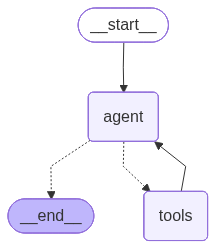

### Agent ↔ Tool Communication Flow

```mermaid

flowchart TD
    U[Driver engineer query\nNatural language input] --> A[LangGraph ReAct Agent\nReason -> Act loop]
    A --> T1[pit_prediction_tool\nML pit recommendation]
    A --> T2[get_race_conditions_tool\nLive race context]
    T1 --> O1[Prediction output\n(pit/stay out + confidence)]
    T2 --> O2[Context output\n(weather, SC, gaps, tyre window)]
    O1 --> F[Decision synthesis]
    O2 --> F
    F --> D[Final strategy call\nYES/NO + why + compound]

```

In [15]:
from IPython.display import display, Markdown, Image

# 1) Try to render the actual LangGraph structure
print("LangGraph (actual compiled agent graph):")
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    mermaid_raw = agent.get_graph().draw_mermaid()
    display(Markdown("```mermaid\n" + mermaid_raw + "\n```"))
    print("PNG rendering not available in this environment; showing Mermaid source diagram instead.")

# 2) Conceptual communication flow: tools -> final strategy decision
tool_names = [t.name for t in tools]
pit_tool_name = tool_names[0] if len(tool_names) > 0 else "pit_prediction_tool"
race_tool_name = tool_names[1] if len(tool_names) > 1 else "get_race_conditions_tool"

flow_mermaid = f"""
flowchart TD
    U[Driver engineer query\\nNatural language input] --> A[LangGraph ReAct Agent\\nReason -> Act loop]
    A --> T1[{pit_tool_name}\\nML pit recommendation]
    A --> T2[{race_tool_name}\\nLive race context]
    T1 --> O1[Prediction output\\n(pit/stay out + confidence)]
    T2 --> O2[Context output\\n(weather, SC, gaps, tyre window)]
    O1 --> F[Decision synthesis]
    O2 --> F
    F --> D[Final strategy call\\nYES/NO + why + compound]
"""

display(Markdown("### Agent ↔ Tool Communication Flow"))
display(Markdown("```mermaid\n" + flow_mermaid + "\n```"))

---
## Step 9 — What Just Happened? Connecting to Azure

Let's make the architecture tangible for the audience.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║   What the agent just did — mapped to Azure              ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Your question (natural language)                        ║
║       │                                                  ║
║       ▼                                                  ║
║  Azure OpenAI / Microsoft Foundry  ← the brain           ║
║  (GPT-4o reasoning + tool calling)                       ║
║       │                                                  ║
║       ├── calls pit_prediction_tool ──────────────────►  ║
║       │     Azure ML real-time endpoint (AKS)            ║
║       │     ← Random Forest model from Part 1            ║
║       │                                                  ║
║       ├── calls get_race_conditions_tool ─────────────►  ║
║       │     Simulated telemetry feed                     ║
║       │     (real version: Azure Event Hubs / IoT Hub)   ║
║       │                                                  ║
║       ▼                                                  ║
║  LangGraph orchestrates the reasoning loop               ║
║  → combines tool outputs                                 ║
║  → generates strategic decision                          ║
║                                                          ║
║  Microsoft Foundry Agent Service (production):           ║
║  → hosts this agent with auto-scaling                    ║
║  → observability in Foundry portal                       ║
║  → enterprise security via Entra ID                      ║
║  → same pattern Mercedes uses at race speed              ║
╚══════════════════════════════════════════════════════════╝
""")

print("\n🏁 Session complete. The pit window is open — go build something fast.")

---
## Resources

- 🔗 [Microsoft × Mercedes-AMG PETRONAS F1 Partnership](https://news.microsoft.com/source/2026/01/22/microsoft-and-mercedes-amg-petronas-f1-team-unite-to-drive-innovation-from-factory-to-circuit/)
- 📚 [Microsoft Foundry Agent Service Docs](https://learn.microsoft.com/en-us/azure/foundry/agents/overview)
- 🦜 [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- 🤖 [Microsoft Agent Framework (GitHub)](https://github.com/microsoft/agent-framework)
- ☁️ [Azure ML — Deploy Real-time Endpoints](https://learn.microsoft.com/en-us/azure/machine-learning/how-to-deploy-online-endpoints)
- 🎓 [Microsoft Learn — AI Fundamentals](https://learn.microsoft.com/en-us/training/paths/get-started-with-artificial-intelligence-on-azure/)

---
*Built for Global Azure — "Lights Out and Away We Go"*  
*🏆 Thank you for attending!*